In [10]:
import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Assignments\HW3')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')


# 加载数据
train_df = pd.read_csv('audit_train.csv')
test_df = pd.read_csv('audit_test.csv')

print("train data:", train_df.shape)
print("test data:", test_df.shape)
print(train_df.columns.tolist())
print(train_df.head())

train data: (576, 25)
test data: (200, 25)
['Sector_score', 'LOCATION_ID', 'PARA_A', 'Score_A', 'Risk_A', 'PARA_B', 'Score_B', 'Risk_B', 'TOTAL', 'numbers', 'Score_B.1', 'Risk_C', 'Money_Value', 'Score_MV', 'Risk_D', 'District_Loss', 'PROB', 'RiSk_E', 'History', 'Prob', 'Risk_F', 'Score', 'CONTROL_RISK', 'Detection_Risk', 'Risk']
   Sector_score LOCATION_ID  PARA_A  Score_A  Risk_A  PARA_B  Score_B  Risk_B  \
0          3.89          23    4.18      0.6   2.508    2.50      0.2   0.500   
1          3.89           6    0.00      0.2   0.000    4.83      0.2   0.966   
2          3.89           6    0.51      0.2   0.102    0.23      0.2   0.046   
3          3.89           6    0.00      0.2   0.000   10.80      0.6   6.480   
4          3.89           6    0.00      0.2   0.000    0.08      0.2   0.016   

   TOTAL  numbers  ...  District_Loss  PROB  RiSk_E  History  Prob  Risk_F  \
0   6.68      5.0  ...              2   0.2     0.4        0   0.2     0.0   
1   4.83      5.0  ...   

Categorical columns: ['LOCATION_ID']
Numerical columns: ['Sector_score', 'PARA_A', 'Score_A', 'Risk_A', 'PARA_B', 'Score_B', 'Risk_B', 'TOTAL', 'numbers', 'Score_B.1', 'Risk_C', 'Money_Value', 'Score_MV', 'Risk_D', 'District_Loss', 'PROB', 'RiSk_E', 'History', 'Prob', 'Risk_F', 'Score', 'CONTROL_RISK', 'Detection_Risk']


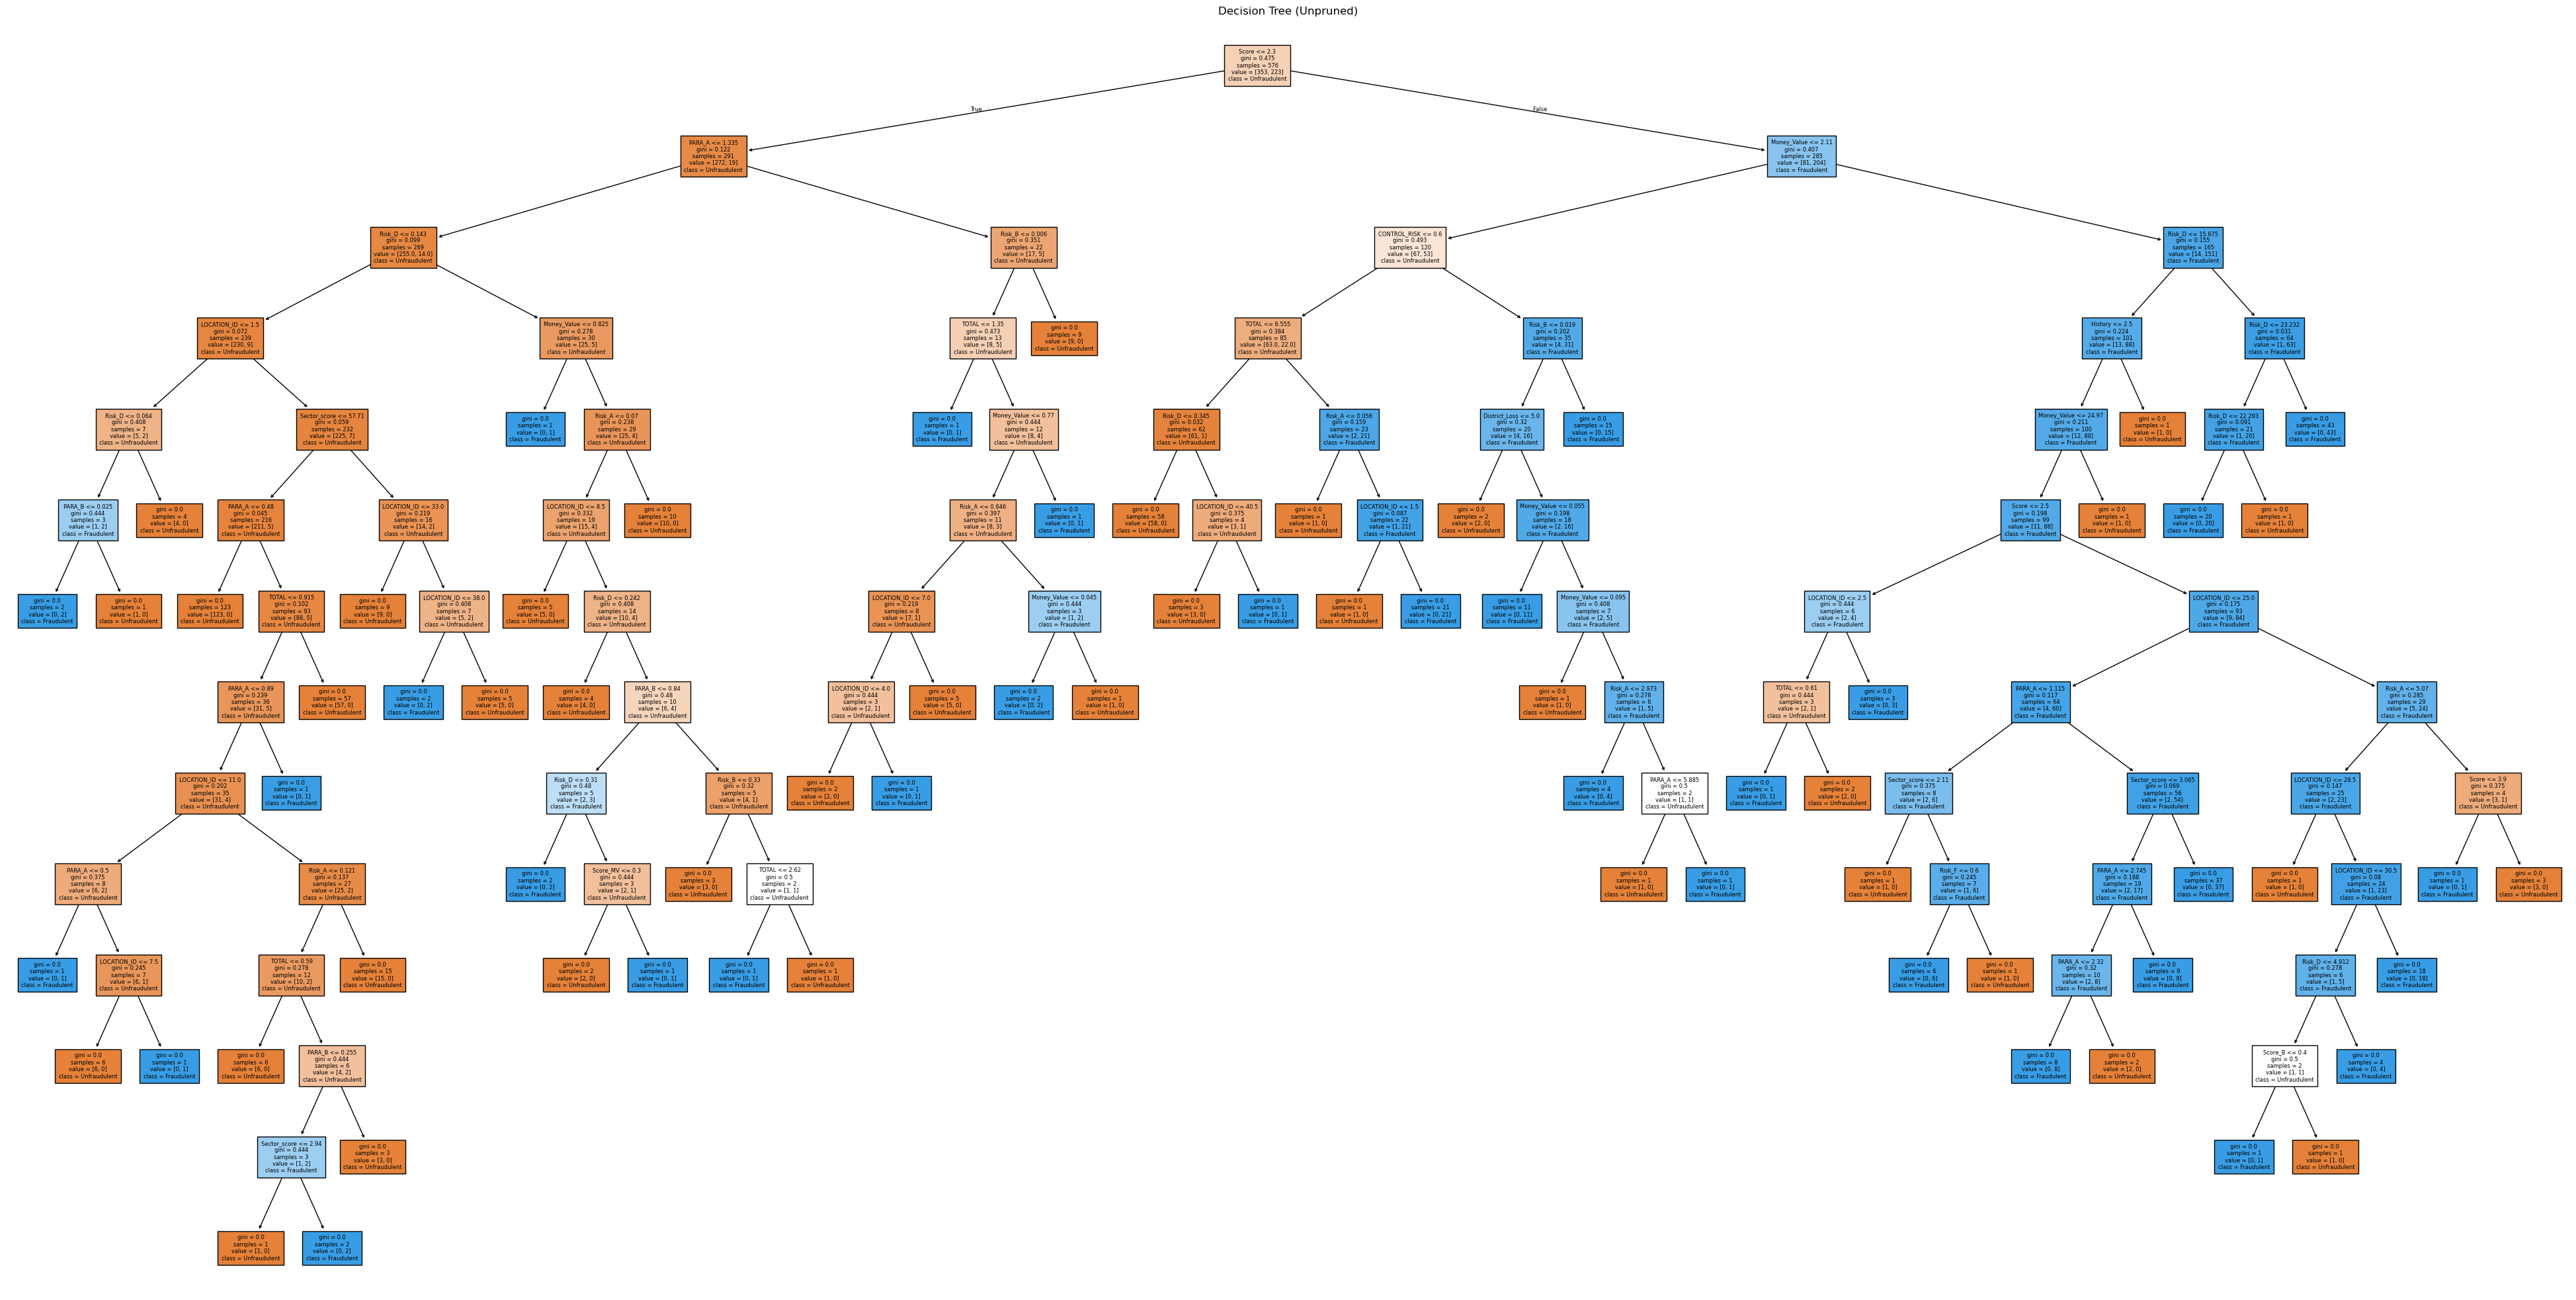

Training Error (Unpruned Decision Tree): 0.0000
Test Error (Unpruned Decision Tree): 0.1250


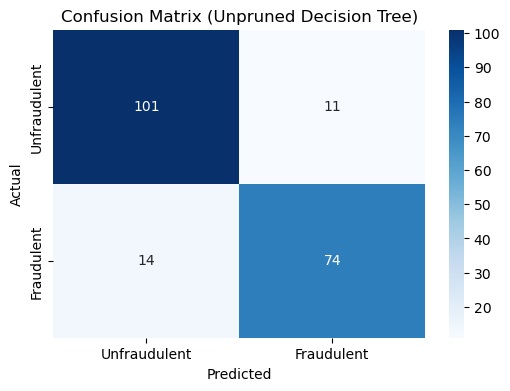

Classification Report (Unpruned Decision Tree):
              precision    recall  f1-score   support

Unfraudulent       0.88      0.90      0.89       112
  Fraudulent       0.87      0.84      0.86        88

    accuracy                           0.88       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.88      0.87       200



In [37]:
# P3_Q1
# Risk=1 means fraudulent, Risk=0 means unfraudulent

y_train = train_df['Risk']
y_test = test_df['Risk']

# 找出分类列（object 类型）
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'Risk']
numerical_cols = [col for col in train_df.columns if col not in categorical_cols and col != 'Risk']

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# 对分类列进行 Label Encoding（处理未见类别）
X_train = train_df.drop(columns=['Risk']).copy()
X_test = test_df.drop(columns=['Risk']).copy()

label_encoders = {}
for col in categorical_cols:
    # 合并训练集和测试集的唯一值
    all_values = pd.concat([X_train[col], X_test[col]]).astype(str).unique()
    le = LabelEncoder()
    le.fit(all_values)  # 编码器知道所有可能的值
    
    # 应用于训练集和测试集
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# print("X_train after encoding:")
# print(X_train.dtypes)

# fit the decision tree model (Unpruned)
dt_clf = DecisionTreeClassifier(random_state=3042)
dt_clf.fit(X_train, y_train)

# plot the decision tree
plt.figure(figsize=(50,25))
plot_tree(
    dt_clf,
    feature_names=X_train.columns,
    class_names=['Unfraudulent', 'Fraudulent'],
    filled=True,      # ← 只保留一个 filled=True
    fontsize=6
)
plt.title("Decision Tree (Unpruned)")
plt.show()

# Predictions and evaluation
y_pred_train = dt_clf.predict(X_train)
train_error = 1 - accuracy_score(y_train, y_pred_train)
print(f"Training Error (Unpruned Decision Tree): {train_error:.4f}")

y_pred_test = dt_clf.predict(X_test)
test_error = 1 - accuracy_score(y_test, y_pred_test)
print(f"Test Error (Unpruned Decision Tree): {test_error:.4f}")

# Confusion Matrix and Classification Report
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Unfraudulent', 'Fraudulent'], 
            yticklabels=['Unfraudulent', 'Fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Unpruned Decision Tree)')
plt.show()

print("Classification Report (Unpruned Decision Tree):")
print(classification_report(y_test, y_pred_test, target_names=['Unfraudulent', 'Fraudulent']))

Best ccp_alpha: 0.003170 with cross-validated error: 0.1371
Number of nodes in the best pruned tree: 9


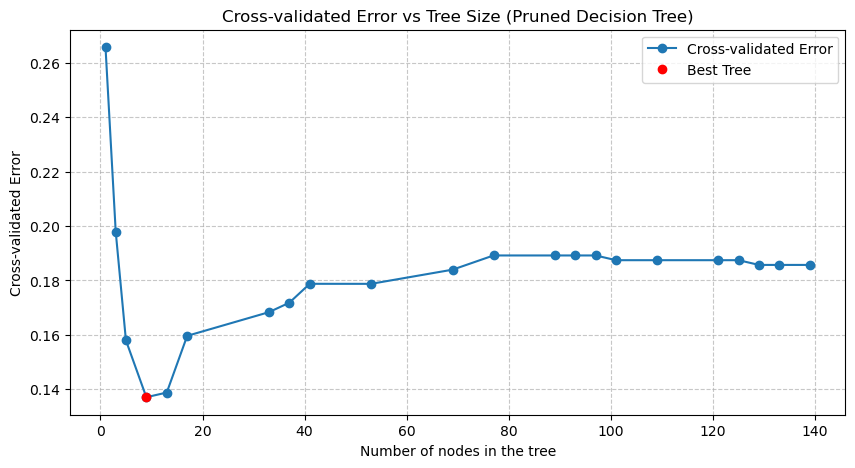

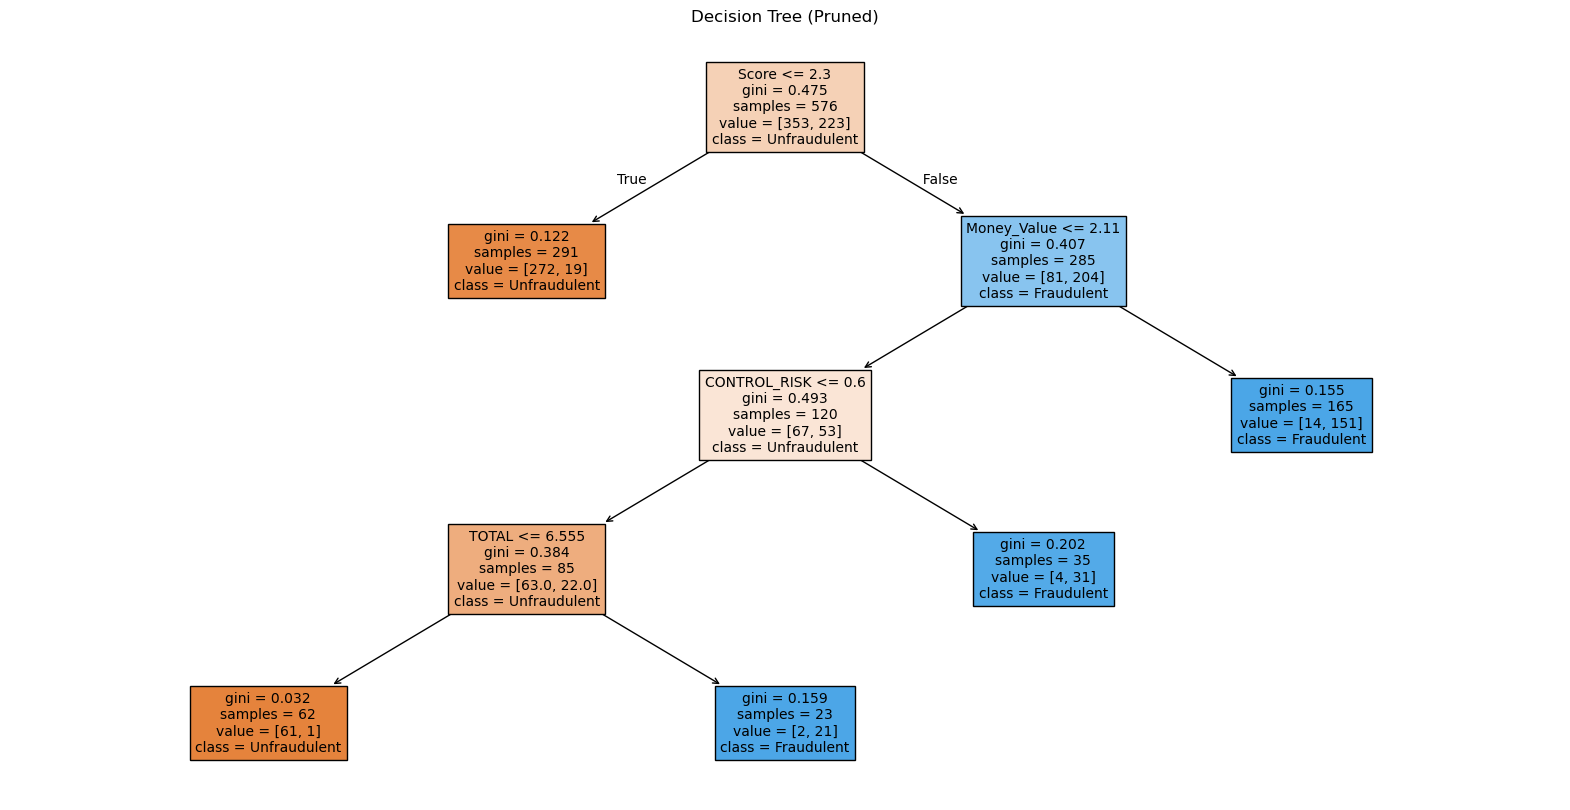

Test Error (Pruned Decision Tree): 0.0450


In [34]:
# P3_Q2

# Get pruning path
path = dt_clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Fit a tree for each ccp_alpha and record tree size
clfs = []
tree_sizes = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=3042, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)  # Fit the tree
    clfs.append(clf)
    tree_sizes.append(clf.tree_.node_count)

# Evaluate each tree with 5-fold CV
cv_scores = []
for clf in clfs:
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(1 - scores.mean())  
# Find the best alpha
best_alpha_index = np.argmin(cv_scores)
best_aplha_clf = clfs[best_alpha_index]
best_alpha = ccp_alphas[best_alpha_index]

print(f"Best ccp_alpha: {best_alpha:.6f} with cross-validated error: {cv_scores[best_alpha_index]:.4f}")
print(f"Number of nodes in the best pruned tree: {best_aplha_clf.tree_.node_count}")

# Fit the final pruned tree (optional, since best_aplha_clf is already fitted)
pruned_dt_clf = best_aplha_clf 

# Plot CV error vs tree size
plt.figure(figsize=(10,5))
plt.plot(tree_sizes, cv_scores, marker='o', label='Cross-validated Error')
plt.plot(tree_sizes[best_alpha_index], cv_scores[best_alpha_index], 'ro', label='Best Tree')
plt.xlabel('Number of nodes in the tree')
plt.ylabel('Cross-validated Error')
plt.title('Cross-validated Error vs Tree Size (Pruned Decision Tree)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot the pruned tree
plt.figure(figsize=(20,10))
plot_tree(
    pruned_dt_clf,
    feature_names=X_train.columns,
    class_names=['Unfraudulent', 'Fraudulent'],
    filled=True,
    fontsize=10
)
plt.title("Decision Tree (Pruned)")
plt.show()

# Report test error
y_test_pred_pruned = pruned_dt_clf.predict(X_test)
test_error_pruned = 1 - accuracy_score(y_test, y_test_pred_pruned)
print(f"Test Error (Pruned Decision Tree): {test_error_pruned:.4f}")

In [38]:
# P3_Q3

# Random Forest with m=13, ntree=25
rf_clf = RandomForestClassifier(
    n_estimators=25,      # ntree=25
    max_features=13,      # m=13
    random_state=3042,     
    n_jobs=-1
)             

# fit the model on training data
rf_clf.fit(X_train, y_train)

# Calculate training error
y_train_pred_rf = rf_clf.predict(X_train)
train_error_rf = 1 - accuracy_score(y_train, y_train_pred_rf)
print(f"Random Forest (m=13, ntree=25) Training Error: {train_error_rf:.6f}")

# print the top 10 most important features
feature_importance = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Random Forest (m=13, ntree=25) Training Error: 0.005208
Top 10 Most Important Features:
TOTAL           0.190700
Score           0.171684
Money_Value     0.153896
Risk_D          0.136590
CONTROL_RISK    0.054967
RiSk_E          0.049475
PARA_A          0.045234
Risk_A          0.039053
LOCATION_ID     0.037207
PARA_B          0.035323
dtype: float64


In [42]:
# P3_Q4

m_values = [8, 12, 14, 16, 18]
train_errors = []
best_m = None
best_rf = None
best_train_error = float('inf')

print("Trying different m values for Random Forest:")
for m in m_values:
    rf = RandomForestClassifier(
        n_estimators=25,      # ntree=25
        max_features=m,       # m 的值
        random_state=3042,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    # calculate training error
    y_train_pred = rf.predict(X_train)
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    train_errors.append(train_error)
    
    print(f"m = {m}, Training Error: {train_error:.6f}")
    
    # find the best model based on training error
    if train_error < best_train_error:
        best_train_error = train_error
        best_m = m
        best_rf = rf

print(f"Best m: {best_m} (smallest training error: {best_train_error:.6f})")

# test the best model on test set
y_test_pred_best = best_rf.predict(X_test)
test_error_best = 1 - accuracy_score(y_test, y_test_pred_best)
print(f"Test Error (Random Forest, m={best_m}): {test_error_best:.6f}")


Trying different m values for Random Forest:
m = 8, Training Error: 0.003472
m = 12, Training Error: 0.006944
m = 14, Training Error: 0.005208
m = 16, Training Error: 0.005208
m = 18, Training Error: 0.006944
Best m: 8 (smallest training error: 0.003472)
Test Error (Random Forest, m=8): 0.040000


In [45]:
# P3_Q5

results = {
    'Model': [],
    'Train Error': [],
    'Test Error': []
}

# Decision tree (unpruned)
y_train_pred_unpruned = dt_clf.predict(X_train)
train_error_unpruned = 1 - accuracy_score(y_train, y_train_pred_unpruned)
y_test_pred_unpruned = dt_clf.predict(X_test)
test_error_unpruned = 1 - accuracy_score(y_test, y_test_pred_unpruned)

results['Model'].append('Unpruned Tree')
results['Train Error'].append(train_error_unpruned)
results['Test Error'].append(test_error_unpruned)

# Decision tree (pruned)
y_train_pred_pruned = pruned_dt_clf.predict(X_train)
train_error_pruned = 1 - accuracy_score(y_train, y_train_pred_pruned)
y_test_pred_pruned = pruned_dt_clf.predict(X_test)
test_error_pruned = 1 - accuracy_score(y_test, y_test_pred_pruned)

results['Model'].append('Pruned Tree')
results['Train Error'].append(train_error_pruned)
results['Test Error'].append(test_error_pruned)

# Random Forest (m=13)
results['Model'].append('RF (m=13)')
results['Train Error'].append(train_error_rf)
results['Test Error'].append(1 - accuracy_score(y_test, rf_clf.predict(X_test)))

# Best Random Forest (m = 8）
results['Model'].append(f'RF (m={best_m})')
results['Train Error'].append(best_train_error)
results['Test Error'].append(test_error_best)

# 转成 DataFrame
results_df = pd.DataFrame(results)
print("Comparison of All Methods:")
print(results_df.to_string(index=False))



Comparison of All Methods:
        Model  Train Error  Test Error
Unpruned Tree     0.000000       0.125
  Pruned Tree     0.069444       0.045
    RF (m=13)     0.005208       0.035
     RF (m=8)     0.003472       0.040


## Key Findings

- **Unpruned Decision Tree**: Achieved zero training error but suffered from severe overfitting, resulting in a high test error of 0.125. This indicates poor generalization to unseen data.
  
- **Pruned Decision Tree**: By applying cost-complexity pruning with cross-validation, the model's test error was significantly reduced to 0.045, demonstrating that pruning effectively mitigates overfitting.

- **Random Forest (m=13)**: Outperformed both decision trees with a test error of 0.035, showcasing the power of ensemble learning in reducing variance and improving stability.

- **Optimal Random Forest (m=8)**: While achieving the lowest training error (0.003472), its test error (0.040) was slightly higher than RF (m=13), suggesting that m=13 strikes a better balance between bias and variance for this dataset.

## Conclusion

The **Random Forest with m=13** achieved the best performance on the test set, making it the most suitable model for predicting audit risk in this scenario. Pruning is essential for decision trees to avoid overfitting, and ensemble methods like Random Forest consistently outperform single tree models due to their ability to average out individual tree errors.